<a href="https://colab.research.google.com/github/tirthendukarmakar/Canvera/blob/main/GENAIPRAC_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.6 MB/s eta 0:00:00


In [9]:
from gensim.models import Word2Vec

sentences = [
    ['the', 'king', 'rules', 'the', 'kingdom'],
    ['the', 'queen', 'rules', 'the', 'kingdom'],
    ['the', 'prince', 'rules', 'the', 'kingdom'],
    ['an', 'apple', 'is', 'a', 'tasty', 'fruit'],
    ['a', 'banana', 'is', 'a', 'tasty', 'fruit'],
    ['an', 'orange', 'is', 'a', 'tasty', 'fruit']
]

print("---Training Models---")

# 1. Train the CBOW model (sg=0)
model_cbow = Word2Vec(sentences, vector_size=10, window=2, min_count=1, sg=0, epochs=100)
print("CBOW model trained successfully.")

# 2. Train the Skip-gram model (sg=1)
model_skipgram = Word2Vec(sentences, vector_size=10, window=2, min_count=1, sg=1, epochs=100)
print("Skip-gram model trained successfully.\n")


# 3. Compare semantic similarities
def test_similarities(model, model_name):
    print(f"---Semantic Similarities using {model_name} ---")

    # Related royal words
    sim_royal = model.wv.similarity('queen', 'king')
    print(f"Similarity ('queen', 'king'):           {sim_royal:.4f}")

    # Related fruit words (using 'banana' which exists in sentences)
    sim_fruit = model.wv.similarity('apple', 'banana')
    print(f"Similarity ('apple', 'is'):         {sim_fruit:.4f}")

    # Unrelated words
    sim_unrelated = model.wv.similarity('queen', 'apple')
    print(f"Similarity ('queen', 'apple'):          {sim_unrelated:.4f}")
    print("-" * 40)


test_similarities(model_cbow, 'CBOW')
test_similarities(model_skipgram, 'Skip-gram')

---Training Models---
CBOW model trained successfully.
Skip-gram model trained successfully.

---Semantic Similarities using CBOW ---
Similarity ('queen', 'king'):           0.4375
Similarity ('apple', 'is'):         -0.1507
Similarity ('queen', 'apple'):          -0.0970
----------------------------------------
---Semantic Similarities using Skip-gram ---
Similarity ('queen', 'king'):           0.4364
Similarity ('apple', 'is'):         -0.1492
Similarity ('queen', 'apple'):          -0.0970
----------------------------------------


### 1. Set up your API Key

To use the GenAI SDK, you'll need an API key. If you don't already have one, you can create one in [Google AI Studio](https://makersuite.google.com/keys).

**Security Best Practice:** In Google Colab, it's recommended to store your API key securely using the "Secrets" feature. Click the "🔑" icon in the left panel, add a new secret, and name it `GOOGLE_API_KEY`. Then, you can access it in your code without exposing it directly in the notebook.

In [ ]:
# Install the Google Generative AI SDK
!pip install -q -U google-generativeai

import google.generativeai as genai
from google.colab import userdata

# Configure the API key
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

print("Google Generative AI SDK configured successfully!")

### 2. Initialize a Generative Model

Once configured, you can initialize a specific generative model. For text generation, `gemini-pro` is a commonly used model.

In [ ]:
# Initialize the Gemini Pro model
gemini_model = genai.GenerativeModel('gemini-pro')

print("Gemini Pro model initialized.")

### 3. Generate Content

Now you can use the `generate_content` method to send prompts to the model and receive responses. Let's try generating a short story.

In [ ]:
# Define your prompt
prompt = "Write a very short story about a cat who discovers a magical ball of yarn."

# Generate content
response = gemini_model.generate_content(prompt)

# Print the generated text
print("\n--- Generated Story ---")
print(response.text)

In [10]:
!pip install gensim --quient

import gensim
from gensim.models import KeyedVectors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Gensim version:", gensim.__version__)


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --quient
Gensim version: 4.4.0


In [11]:
import gensim.downloader as api

#This automatically downloads and caches
model = api.load("word2vec-google-news-300")

#Test if it automatically
print(model.most_similar("google"))

[==================================================] 100.0% 1662.8/1662.8MB downloaded
[('google.com', 0.6711485981941223), ('google_yahoo', 0.6488178968429565), ('wikipedia', 0.643608033657074), ('www.google.com', 0.6258559226989746), ('googled', 0.6166064143180847), ('googling', 0.6086059212684631), ('slashdot', 0.5964587330818176), ('lifehacker', 0.5948858857154846), ('gizmodo', 0.5884420275688171), ('inurl', 0.5882638692855835)]


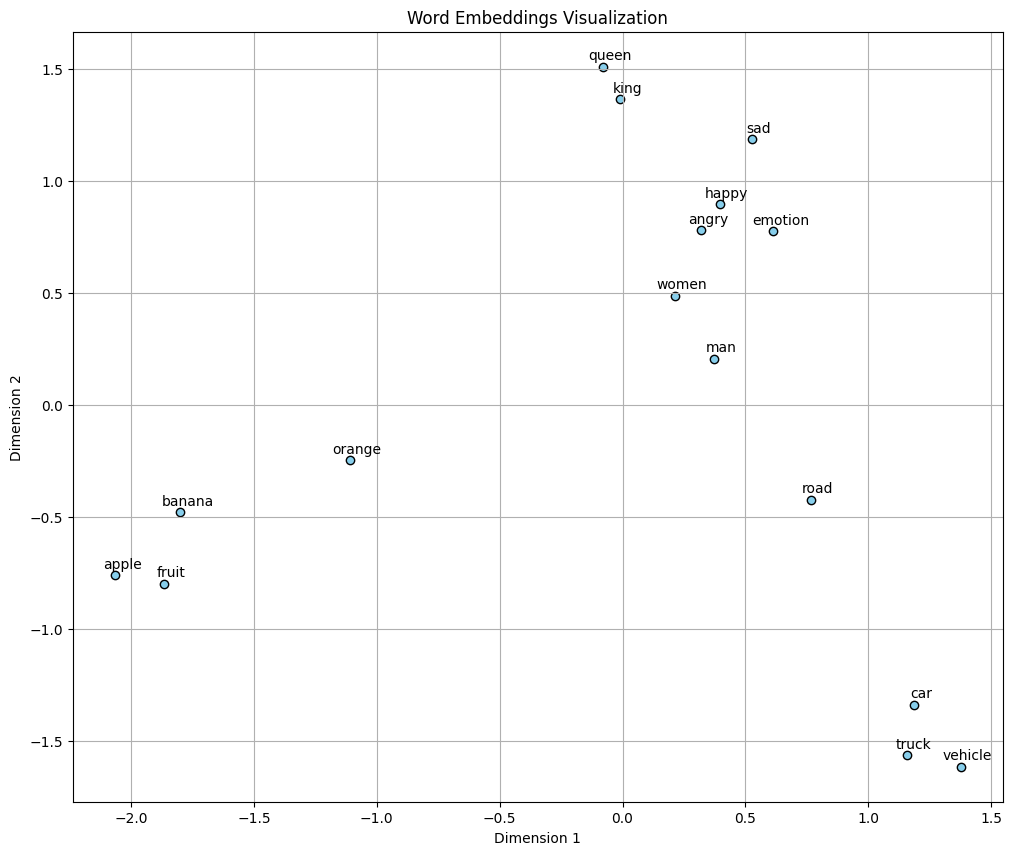

In [14]:
word_to_visualize = [
    'king','queen','man','women',
    'apple','banana','orange','fruit',
    'car','truck','vehicle','road',
    'happy','sad','angry','emotion'
]

filtered_words = [word for word in word_to_visualize if word in model.key_to_index]
vectors = [model[word] for word in filtered_words]

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)


plt.figure(figsize=(12, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1],edgecolors='k',c='skyblue')

for i, word in enumerate(filtered_words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),textcoords="offset points",xytext=(5, 5),ha='center')

plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Word Embeddings Visualization')
plt.grid(True)
plt.show()